In [2]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
from collections import deque
import random
import pygame
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

from snake import SnakeEnv

In [3]:
if __name__ == "__main__":
    env = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
    obs, info = env.reset()
 
    total_reward = 0
    episodio = 1
 
    print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
    print("-" * 55)
 
    while env.running:
        action = env.action_space.sample() # Elige una acción aleatoria entre [0, 1, 2]
 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
 
        env.render()
 
        if terminated or truncated:
            causa = info.get("cause") or "max_steps"
            print(f"{episodio:>9} | {total_reward:>10.2f} | {len(env.snake):>8} | {causa}")
            episodio += 1
            total_reward = 0
            obs, info = env.reset()
 
    env.close()


 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |     -20.70 |        3 | collision
        2 |     -20.25 |        3 | obstacle
        3 |     -20.13 |        4 | bad_food


In [16]:
if __name__ == "__main__":
    env = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
    obs, info = env.reset()

    env.render()
    
    # Mapeo de teclas a direcciones absolutas (0: Arriba, 1: Derecha, 2: Abajo, 3: Izquierda)
    KEY_TO_DIR = {
        pygame.K_UP: 0,
        pygame.K_RIGHT: 1,
        pygame.K_DOWN: 2,
        pygame.K_LEFT: 3
    }
    
    while env.running:
        # Gestiona la velocidad para que un humano pueda jugar
        env.clock.tick(10)

        # Por defecto, la acción es 1 (seguir recto)
        action = 1 
        
        # Capturamos eventos de teclado
        pygame.event.pump()
        keys = pygame.key.get_pressed()
        
        # Determina qué dirección absoluta quiere el usuario
        desired_dir = -1
        for key, direction in KEY_TO_DIR.items():
            if keys[key]:
                desired_dir = direction
                break
        
        # Traduce la dirección absoluta a acción relativa (giro)
        if desired_dir != -1:
            current_dir = env.direction
            
            # Calculamos la diferencia de giro
            diff = (desired_dir - current_dir) % 4
            
            if diff == 3: # Ir a la izquierda
                action = 0
            elif diff == 1: # Ir a la derecha
                action = 2
            elif diff == 0: # Misma dirección
                action = 1

        # Aplica la acción en el entorno
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()

        # Reinicio si muere
        if terminated or truncated:
            print(f"Fin del juego. Causa: {info.get('cause')}. Reiniciando...")
            obs, info = env.reset()

    env.close()

Fin del juego. Causa: collision. Reiniciando...
Fin del juego. Causa: collision. Reiniciando...
Fin del juego. Causa: collision. Reiniciando...
Fin del juego. Causa: collision. Reiniciando...
Fin del juego. Causa: collision. Reiniciando...
Fin del juego. Causa: bad_food. Reiniciando...
Fin del juego. Causa: obstacle. Reiniciando...
Fin del juego. Causa: collision. Reiniciando...
Fin del juego. Causa: bad_food. Reiniciando...
Fin del juego. Causa: collision. Reiniciando...


La lista que nos devuelve _get_obsertions ya viene normalizada a excepción del último valor ``length_norm``, dicho valor es continuo, por lo que hay infinitos valores distintos, como el agente visitaría cada estado 1 sola vez nunca generalizaría, por lo que la tabla Q nunca convergirá, al discretizar todos los valores colapsan a la misma clave

In [4]:
"""Más bins = más granularidad, pero tabla Q más grande y más lenta de converger. 5 es un valor razonable para empezar. """

N_BINS = 5

def discretizar_estado(obs: np.ndarray, n_bins = N_BINS) -> tuple:
    """
    Convierte el vector de observación continuo en una tupla hashable
    que puede usarse como clave en la tabla Q.

    Las primeras 13 features son binarias → se convierten a int directamente.
    La feature 13 (length_norm) se discretiza en n_bins intervalos uniformes.
    """
    # Features binarias [0-12]
    estado_discreto = tuple(int(round(x)) for x in obs[:13])

    # Feature continua [13]: longitud normalizada → bin entre 0 y n_bins-1
    bin_longitud = min(int(obs[13] * n_bins), n_bins - 1)

    return estado_discreto + (bin_longitud,)


# Verificación rápida
env_test = SnakeEnv()
obs, _ = env_test.reset()
estado = discretizar_estado(obs)
print(f"Observación original (14 floats): {obs}")
print(f"Estado discretizado  (14 ints)  : {estado}")
print(f"Tipo de la clave: {type(estado)} — hashable: {isinstance(estado, tuple)}")

Observación original (14 floats): [0.   0.   0.   0.   1.   0.   0.   1.   0.   0.   1.   0.   0.   0.03]
Estado discretizado  (14 ints)  : (0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0)
Tipo de la clave: <class 'tuple'> — hashable: True


## Monte Carlo


In [5]:
def elegir_accion_epsilon_greedy(estado: int, Q: defaultdict, epsilon: float) -> int:
    """
    Recibe un estado y una tabla Q y devuelve una acción usando una
    política epsilon-greedy. Si el estado no existe en Q, se inicializa en 0.
    """

    # Exploración: elige una acción aleatoria con probabilidad epsilon
    if np.random.random() < epsilon:
        return int(np.random.choice(SnakeEnv().action_space.n))

    # Explotación: toma la acción que maximiza el valor Q 
    return int(np.argmax(Q[estado]))

def monte_carlo_control(env: SnakeEnv, num_episodios: int, trace: int, epsilon: float, gamma: float):
    """
    Entrena un agente usando el método de Control de Monte Carlo.
    """

    # Tabla Q: cada estado tiene un array de 3 ceros (uno por acción)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    # Contador de visitas a cada par estado-acción
    visitas = defaultdict(lambda: np.zeros(env.action_space.n))

    historico_recompensas = []

    for i in range(num_episodios):
        episodio = []
        obs, _ = env.reset()
        estado = discretizar_estado(obs)
        terminado = False
        truncado = False
        recompensa_total_episodio = 0

        # Genera un episodio completo
        while not (terminado or truncado):
            accion = elegir_accion_epsilon_greedy(estado, Q, epsilon)
            proxima_obs, recompensa, terminado, truncado, _ = env.step(accion)
            
            # Guardamos la transición
            episodio.append((estado, accion, recompensa))
            
            estado = discretizar_estado(proxima_obs)
            recompensa_total_episodio += recompensa

        historico_recompensas.append(recompensa_total_episodio)

        # Actualización de la tabla Q
        G = 0

        # Recorremos el episodio a la inversa para calcular los retornos
        for t in reversed(range(len(episodio))):
            est, acc, rec = episodio[t]
            G = rec + gamma * G
            
            # Calcula la media iterativa
            visitas[est][acc] += 1
            n = visitas[est][acc]
            Q[est][acc] += (1 / n) * (G - Q[est][acc])

        if (i + 1) % trace == 0:
            print(f"Episodio {i+1}/{num_episodios} | Recompensa media: {np.mean(historico_recompensas[-trace:]):.2f}")

    return Q, historico_recompensas


In [ ]:
num_episodios = 100000
trace = 10000
gamma = 0.99

Qs = {}
recompensas = {}

for epsilon in [0.2, 0.1, 0.05, 0.01, 0]:
    env = SnakeEnv()
    Q_final, historico_recompensas = monte_carlo_control(env=env, num_episodios=num_episodios,
                                                         trace=trace, epsilon=epsilon, gamma=gamma)
    Qs[epsilon] = Q_final
    recompensas[epsilon] = historico_recompensas

Episodio 10000/100000 | Recompensa media: -8.59
Episodio 20000/100000 | Recompensa media: -7.86
Episodio 30000/100000 | Recompensa media: -7.56
Episodio 40000/100000 | Recompensa media: -7.63
Episodio 50000/100000 | Recompensa media: -7.56
Episodio 60000/100000 | Recompensa media: -7.69
Episodio 70000/100000 | Recompensa media: -7.59
Episodio 80000/100000 | Recompensa media: -7.67
Episodio 90000/100000 | Recompensa media: -7.56
Episodio 100000/100000 | Recompensa media: -7.52
Episodio 10000/100000 | Recompensa media: 7.73
Episodio 20000/100000 | Recompensa media: 10.50
Episodio 30000/100000 | Recompensa media: 11.57
Episodio 40000/100000 | Recompensa media: 12.07
Episodio 50000/100000 | Recompensa media: 11.88
Episodio 60000/100000 | Recompensa media: 12.16
Episodio 70000/100000 | Recompensa media: 12.49
Episodio 80000/100000 | Recompensa media: 12.40
Episodio 90000/100000 | Recompensa media: 12.96
Episodio 100000/100000 | Recompensa media: 13.04
Episodio 10000/100000 | Recompensa medi

In [20]:
from joblib import Parallel, delayed

# Función auxiliar para ejecutar un entrenamiento individual
def ejecutar_experimento(num_episodios, trace, epsilon, gamma):
    env = SnakeEnv()
    Q, historico_recompensas = monte_carlo_control(env=env, num_episodios=num_episodios,
                                                   trace=trace, epsilon=epsilon, gamma=gamma)
    env.close()
    return epsilon, Q, historico_recompensas


if __name__ == "__main__":
    # Parámetros de los experimentos
    epsilons = [0.2, 0.1, 0.05, 0.01, 0]
    num_episodios = 500_000
    trace = 100
    gamma = 0.99

    # Creamos un Pool de procesos para paralelizar los entrenamientos con diferentes epsilons
    resultados = Parallel(n_jobs=-1)(
        delayed(ejecutar_experimento)(num_episodios, trace, eps, gamma) for eps in epsilons)

    # Organizamos los resultados en diccionarios para su análisis posterior
    Qs = {}
    recompensas = {}
    for eps, q_res, hist_res in resultados:
        Qs[eps] = q_res
        recompensas[eps] = hist_res


c:\Users\jcarr\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


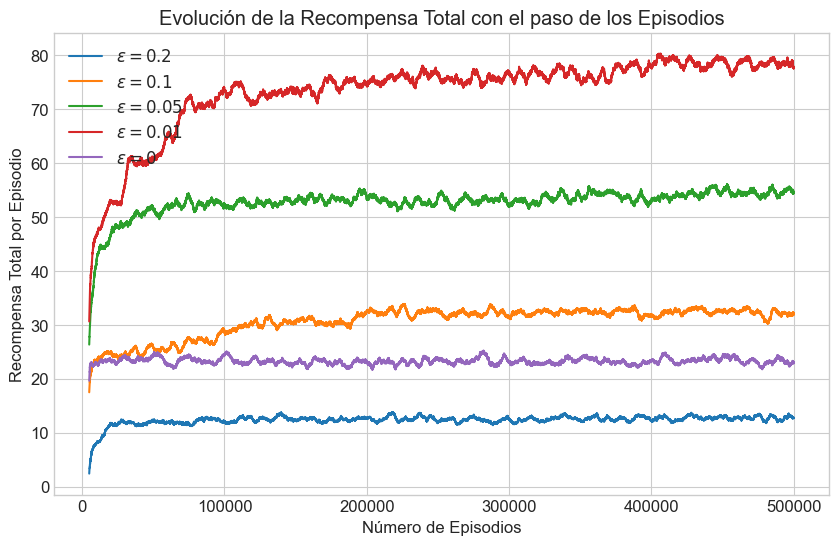

In [24]:
# Configuración de estilo para gráficas (opcional, mejora la estética)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

ventana = num_episodios // 100

# Gráfica
plt.figure(figsize=(10, 6))

for epsilon, recompensas_eps in recompensas.items():
    recompensas_suavizadas = pd.Series(recompensas_eps).rolling(window=ventana).mean()
    plt.plot(recompensas_suavizadas, label=rf'$\epsilon={epsilon}$')

plt.xlabel('Número de Episodios')
plt.ylabel('Recompensa Total por Episodio')
plt.title('Evolución de la Recompensa Total con el paso de los Episodios')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
if __name__ == "__main__":
    env = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
    obs, info = env.reset()
 
    total_reward = 0
    episodio = 1
 
    print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
    print("-" * 55)
 
    while env.running:
        # Política aprendida: elige la acción con mayor valor Q para el estado actual
        action = int(np.argmax(Qs[0.01][discretizar_estado(obs)]))
 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
 
        env.render()
 
        if terminated or truncated:
            causa = info.get("cause") or "max_steps"
            print(f"{episodio:>9} | {total_reward:>10.2f} | {len(env.snake):>8} | {causa}")
            episodio += 1
            total_reward = 0
            obs, info = env.reset()
 
    env.close()


 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |     159.67 |       20 | collision
        2 |      53.99 |       10 | collision
        3 |      -9.75 |        4 | obstacle
        4 |      23.28 |        8 | bad_food
        5 |      74.82 |       12 | collision


## Q-learning


## Política Epsilon-Greedy

Usamos una política $\epsilon$-greedy:
- Con probabilidad $\epsilon$ → acción **aleatoria** (explorar)
- Con probabilidad $1-\epsilon$ → $\arg\max_a Q(s, a)$ (explotar)

En caso de empate entre los valores Q máximos, elegimos al azar entre los mejores para evitar un sesgo sistemático.

In [45]:
def elegir_accion(estado: tuple, Q: defaultdict, epsilon: float, n_acciones: int = 3) -> int:

    if np.random.random() < epsilon:
        return np.random.randint(n_acciones)

    q_valores = Q[estado]

    # Rompemos los empates aleatoriamente
    max_q   = np.max(q_valores)
    mejores = np.where(q_valores == max_q)[0]
    return int(np.random.choice(mejores))

$$Q(s, a) \leftarrow Q(s, a) + \alpha \underbrace{\left( \underbrace{r + \gamma \cdot \max_{a'} Q(s', a')} - Q(s, a) \right)}$$

In [46]:
class AgenteQLearning:

    def __init__(
        self,
        alpha: float         = 0.1,
        gamma: float         = 0.95,
        epsilon: float       = 1.0,
        epsilon_min: float   = 0.01,
        epsilon_decay: float = 0.995,
        n_acciones: int      = 3,
    ):
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_acciones    = n_acciones

        # Tabla Q: estado (tupla) → array de valores Q por acción
        self.Q = defaultdict(lambda: np.zeros(self.n_acciones))

    def get_accion(self, observacion: np.ndarray) -> int:
        estado = discretizar_estado(observacion)
        return elegir_accion(estado, self.Q, self.epsilon, self.n_acciones)

    def actualizar_tabla_Q(self, observacion, accion, recompensa, obs_siguiente, terminado):
        s  = discretizar_estado(observacion)
        s_ = discretizar_estado(obs_siguiente)
        max_q = np.max(self.Q[s_]) if not terminado else 0.0
        self.Q[s][accion] += self.alpha * (recompensa + self.gamma * max_q - self.Q[s][accion])

    def decay_epsilon(self):
        # FIX 1: asignar el resultado a self.epsilon en lugar de solo devolverlo
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def estados_conocidos(self):
        return len(self.Q)

In [47]:
def entrenamiento_Q_learning(
        env,
        num_episodios  = 10_000,
        alpha          = 0.1,
        gamma          = 0.95,
        epsilon        = 1.0,
        epsilon_min    = 0.01,
        epsilon_decay  = 0.995,
        intervalo_log  = 500):

    agente = AgenteQLearning(
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
    )

    metricas: dict = {
        "recompensas": [],
        "longitudes":  [],
        "causas":      [],
        "epsilons":    [],
        "estados_Q":   [],
    }

    print(f"{'Episodio':>10} | {'R. Media':>10} | {'Long. Media':>12} | {'Epsilon':>8} | {'Estados Q':>10}")
    print("-" * 62)

    for ep in range(1, num_episodios + 1):
        obs, _ = env.reset()
        recompensa_total = 0.0
        terminado = truncado = False

        while not (terminado or truncado):
            accion = agente.get_accion(obs)
            obs_sig, recompensa, terminado, truncado, info = env.step(accion)
            agente.actualizar_tabla_Q(obs, accion, recompensa, obs_sig, terminado or truncado)
            obs = obs_sig
            recompensa_total += recompensa

        agente.decay_epsilon()

        metricas["recompensas"].append(recompensa_total)
        metricas["longitudes"].append(len(env.snake))
        metricas["causas"].append(info.get("cause") or "max_steps")
        metricas["epsilons"].append(agente.epsilon)
        metricas["estados_Q"].append(agente.estados_conocidos())  # FIX 2: paréntesis

        # FIX 3: bloque de log que faltaba
        if ep % intervalo_log == 0:
            ventana_r = metricas["recompensas"][-intervalo_log:]
            ventana_l = metricas["longitudes"][-intervalo_log:]
            print(
                f"{ep:>10} | "
                f"{np.mean(ventana_r):>10.2f} | "
                f"{np.mean(ventana_l):>12.2f} | "
                f"{agente.epsilon:>8.4f} | "
                f"{agente.estados_conocidos():>10}"  # FIX 2: paréntesis
            )

    print("\nEntrenamiento finalizado.")
    print(f"Estados únicos explorados: {agente.estados_conocidos()}")  # FIX 2: paréntesis
    return agente, metricas

Entrenamiento del modelo

In [48]:
env = SnakeEnv(grid_size=10, render_mode=None, max_steps=500)

agente, metricas = entrenamiento_Q_learning(
    env,
    num_episodios  = 10_000,
    alpha          = 0.1,     # Tasa de aprendizaje
    gamma          = 0.95,    # Factor de descuento del MDP
    epsilon        = 1.0,     # Exploración inicial total
    epsilon_min    = 0.01,    # Mínimo 1% de exploración siempre
    epsilon_decay  = 0.995,   # Decaimiento multiplicativo por episodio
    intervalo_log  = 500,
)

  Episodio |   R. Media |  Long. Media |  Epsilon |  Estados Q
--------------------------------------------------------------
       500 |      -1.21 |         4.81 |   0.0816 |        299
      1000 |      47.60 |         9.46 |   0.0100 |        480
      1500 |      62.43 |        10.88 |   0.0100 |        591
      2000 |      61.70 |        10.82 |   0.0100 |        654
      2500 |      64.91 |        11.11 |   0.0100 |        692
      3000 |      68.41 |        11.45 |   0.0100 |        722
      3500 |      62.38 |        10.87 |   0.0100 |        751
      4000 |      66.73 |        11.29 |   0.0100 |        775
      4500 |      68.86 |        11.49 |   0.0100 |        795
      5000 |      71.45 |        11.74 |   0.0100 |        822
      5500 |      71.37 |        11.73 |   0.0100 |        842
      6000 |      72.85 |        11.87 |   0.0100 |        856
      6500 |      71.55 |        11.75 |   0.0100 |        865
      7000 |      76.56 |        12.22 |   0.0100 |    

Visualización del resultado de como juega la serpiente

In [ ]:
# El agente juega en modo codicioso: epsilon = 0 → siempre elige argmax Q(s,a)

epsilon_guardado = agente.epsilon
agente.epsilon   = 0.0          # Sin exploración: pura explotación de la tabla Q

env_vis = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
obs, _  = env_vis.reset()

recompensa_total = 0.0
episodio         = 1

print("Agente Q-Learning jugando. Pulsa ESC o cierra la ventana para salir.")
print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
print("-" * 55)

while env_vis.running:
    accion = agente.get_accion(obs)
    obs, recompensa, terminado, truncado, info = env_vis.step(accion)
    recompensa_total += recompensa
    env_vis.render()

    if terminado or truncado:
        causa = info.get("cause") or "max_steps"
        print(f"{episodio:>9} | {recompensa_total:>10.2f} | {len(env_vis.snake):>8} | {causa}")
        episodio        += 1
        recompensa_total = 0.0
        obs, _           = env_vis.reset()

env_vis.close()
agente.epsilon = epsilon_guardado   # Restaurar epsilon original
print("\nVisualización cerrada.")

Agente Q-Learning jugando. Pulsa ESC o cierra la ventana para salir.
 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |     135.48 |       18 | collision
        2 |      95.08 |       14 | collision
        3 |      73.64 |       12 | bad_food
        4 |      96.31 |       14 | collision
        5 |      61.28 |       11 | bad_food
        6 |      62.19 |       11 | bad_food
        7 |      52.27 |       10 | collision
        8 |      65.24 |       11 | collision
        9 |     136.15 |       18 | bad_food
       10 |     137.01 |       18 | obstacle
       11 |     147.96 |       19 | bad_food
       12 |     220.17 |       26 | bad_food
       13 |      92.79 |       14 | collision

Visualización cerrada.
